In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Interest Rates

In the Vasicek model, $r(t)$ is the instantaneous risk‑free interest rate at time $t$, which is also called the short rate. To use $r(t)$ for discounting, the ciscount factor from time $T$ to time $t$ is $$D(t,T) = \exp\left(-\int_t^T r_s ds\right).$$

> **In this notebook, we simulate the Vasicek short‑rate model to price an $n$‑year zero‑coupon bond at any time $t$ between issuance and maturity.**

- **Pricing zero‑coupon (discount) bonds.**  Longer‑maturity risk‑free rates are built from this short rate. The price of a zero‑coupon bond (discount bond) is determined by the expected average path of $r(t)$ between today and maturity.

- **Mean reversion.** In the Vasicek model, $r(t)$ is mean‑reverting: it moves randomly with market shocks, but is pulled toward a long‑run level $b$. This feature produces a realistic, dynamic term structure of interest rates and allows us to price discount bonds consistently across maturities.

# Vasicek Short-Rate Model

The Vasicek short‑rate model is given by the SDE
$$dr_t = a\,(b - r_t)\,dt + \sigma\, dW_t ,$$
where $W_t$ is a standard Brownian motion.  This is a linear SDE (Ornstein–Uhlenbeck process). Use an integrating factor $e^{a t}$, we get:
$$d\big(e^{a t} r_t\big) = a b e^{a t} dt + \sigma e^{a t} dW_t.$$
Then integrate from $0$ to $t$ to solve for $r(t)$:
$$r_t=r_0 e^{-at}+b(1-e^{-at})+\sigma e^{-at}\int^t_0 e^{as} dW_s$$

 the Vasicek model is a single-factor short-rate model. A single-factor model is one that only recognizes one factor that affects market returns by accounting for interest rates. In this case, market risk is what affects interest rate changes.

## Parameters
- $a$ – Speed of mean reversion, how fast $r_t$ is pulled back toward the long‑run level $b$.
- $b$ – Long‑run mean level, the level of the short rate toward which the process mean‑reverts.
- $\sigma$ – Volatility, the instantaneous standard deviation of shocks to the short rate.
- $r_0$ – Initial short rate, the value of $r_t$ at time $0$.
- $t$ – Time.
- $W_s$ – Brownian motion, a standard Wiener process.  In particular, let $I(t)=\int^t_0 e^{as} dW_s,$ we have $$I(t)\sim \mathcal{N}(0,Var(I(t))),$$ where $Var(I(t))=\int^t_0 e^{2as} ds=\dfrac{e^{2at}-1}{2a}$ if $a\not=0$. 

## Analytic Mean and Variance

$$E[r_t]=r_0e^{-at}+b(1-e^{-at})$$
$$Var[r_t]=\dfrac{\sigma^2}{2a}(1-e^{-2at})$$

## Monte-Carlo Simulation against analytic mean formula



In [2]:
# define constants
r0 = 0.045
a = 0.4 
b = 0.03 
sigma = 0.008
T = 3 # in years
n_steps = 100
n_sim = 20
timeline = np.linspace(0, T, num=n_steps)
dt = T / (n_sim - 1)


# set random variable values
rng = np.random.default_rng(seed=120)
std_normal_sample =  rng.standard_normal(size=(n_steps-1, n_sim))


# initiate np arrays
interest_rate = np.zeros((n_steps,n_sim))
interest_rate[0,:] = r0
average_rate = np.zeros(n_steps)
average_rate[0] = r0


# simulate the Vasicek model for n_sim many simulations 
for i in range(n_steps - 1): 
    interest_rate[i+1,:] = interest_rate[i,:] * np.exp(-1 * a * dt) + b * (1 - np.exp(-1 * a * dt)) +\
    sigma * np.exp(-1 * a * dt) * np.sqrt((np.exp(2 * a * dt) - 1) / (2 * a)) * std_normal_sample[i,:]

    average_rate[i+1] = average_rate[i] * np.exp(-1 * a * dt) + b * (1 - np.exp(-1 * a * dt))
    

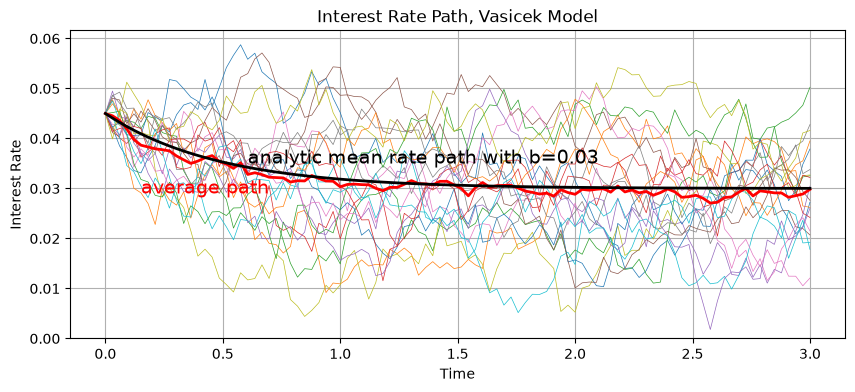

In [3]:
plt.figure(figsize=(10, 4))

# Plot simulations with a for loop
for i in range(n_sim):
    plt.plot(timeline, interest_rate[:,i], linewidth=0.5)  


# Plot the average rate path obtained by taking the average over all simulations
plt.plot(timeline, np.average(interest_rate, axis=1), 'r-', linewidth=2)
plt.text(timeline[int(n_steps/18)], np.average(interest_rate, axis=1)[int(n_steps/2)], 'average path', color='r', va='center', ha='left', size=14)


# Plot the analytic mean rate path obtained with E[r(t)]
plt.plot(timeline, average_rate, 'k-', linewidth=2)
plt.text(timeline[int(n_steps/5)], b*1.2, f'analytic mean rate path with b={b}', color='k', va='center', ha='left', size=14)


plt.xlabel('Time')
plt.ylabel('Interest Rate')
plt.ylim(bottom=0)
plt.title('Interest Rate Path, Vasicek Model')
plt.grid(True)
plt.show()

# Using the Vasicek Model to price discount bonds

A **discount bond** (zero coupon bond) makes no intermediate coupon payments and pays a single amount (its face value) at maturity. Its price today is then  the present value of 1 dollar received at the maturity date.

### Parameters
- $t$ is any time point between issurance ($t=0$) and maturity ($t=T$).
- $T$ is the maturity date of the discount bond.

### Pricing
Prices of a discount bond issued at $t=0$ and matures at $t=T$ at time $t$ is given by: 
$$P(t,T) = A(t,T)e^{-B(t,T)r(t)},$$ where

$$B(t,T) = \dfrac{1-e^{-a(T-t)}}{a},\,A(t,T)=\exp\left( (b-\frac{\sigma^2}{2a^2}) [B-(T-t)] - \frac{\sigma^2}{4a}B^2\right).$$


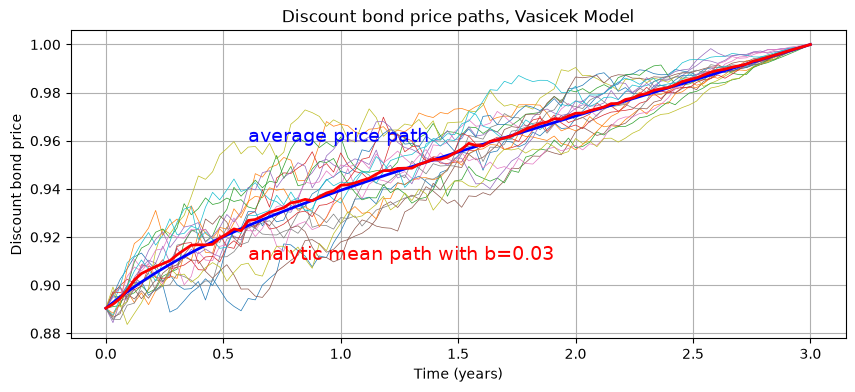

In [4]:
B = (1 - np.exp(-1 * a * ( T - timeline ))) / a
A = np.exp(
    (b - sigma**2 / (2 * a**2)) * (B - T + timeline) - sigma**2 / (4 * a) * B**2
)
P = A[:,None] * np.exp(-1 * B[:,None] * interest_rate)


plt.figure(figsize=(10, 4))

# Plot simulations with a for loop
for i in range(n_sim):
    plt.plot(timeline, P[:,i], linewidth=0.5)  


# Plot the average price path obtained by taking the average over all simulations
price_if_rate_is_avg = A * np.exp(-1 * B * average_rate)
plt.plot(timeline, price_if_rate_is_avg, 'b-', linewidth=2)
plt.text(timeline[int(n_steps/5)], np.average(P, axis=1)[int(n_steps/10)],  f'analytic mean path with b={b}', color='r', va='center', ha='left', size=14)


# Plot the analytic mean price path, assuming r(t)=E[r(t)]
plt.plot(timeline, np.average(P, axis=1), 'r-', linewidth=2)
plt.text(timeline[int(n_steps/5)], price_if_rate_is_avg[0]*1.08, 'average price path', color='b', va='center', ha='left', size=14)

plt.xlabel('Time (years)')
plt.ylabel('Discount bond price')
plt.title('Discount bond price paths, Vasicek Model')
plt.grid(True)
plt.show()